<a href="https://colab.research.google.com/github/gravity102424/ESAA/blob/main/ESAA_OB_week10_2_Time_Series(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 7.5 LSTM

RNN은 결정적 단점이 있다. 앞서 언급했듯이 가중치가 업데이트되는 과정에서 기울기가 1보다 작은 값이 계속 곱해지기 때문에 기울기가 사라지는 기울기 소멸 문제가 발생한다. 이를 해결하기 위해 LSTM이나 GRU 같은 확장된 RNN 방식들을 사용하고 있다.

## 7.5.1 LSTM 구조

LSTM 구조는 순전파와 역전파 과정으로 살펴보겠다.

## LSTM 순전파

LSTM은 기울기 소멸 문제를 해결하기 위해 망각 게이트, 입력 게이트, 출력 게이트라는 새로운 요소를 은닉층의 각 뉴런에 추가했다.

## 망각 게이트

forget gate는 과거 정보를 어느 정도 기억할지 결정한다. 과거 정보와 현재 데이터를 입력받아 시그모이드를 취한 후 그 값을 과거 정보에 곱해 준다. 따라서 시그모이드의 출력이 0이면 과거 정보는 버리고, 1이면 과거 정보는 온전히 보존한다.

0과 1 사이의 출력 값을 가지는 $h_{t-1}$과 $x_t$를 입력 값으로 받는다. 이때 $x_t$는 새로운 입력 값이고 $h_{t-1}$은 이전 은닉층에서 입력되는 값이다. 즉, $h_{t-1}$과 $x_t$를 이용하여 이전 상태 정보를 현재 메모리에 반영할지 결정하는 역할을 한다.

* 계산한 값이 1이면 바로 직전의 정보를 메모리에 유지

* 계산한 값이 0이면 초기화

망각 게이트에 대한 수식은 다음과 같다.

$f_t$ = $\sigma$($w_f$[$h_{t-1}$,$x_t$])

$c_t$ = $f_t$*$c_{t-1}$

그림으로는 다음과 같이 표현할 수 있다.

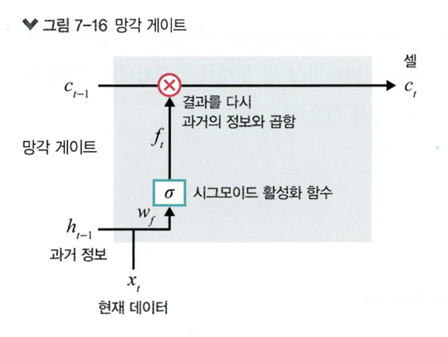



## 입력 게이트

입력 게이트(input gate)는 현재 정보를 기억하기 위해 만들어졌다. 과거 정보와 현재 데이터를 입력받아 시그모이드와 하이퍼볼릭 탄젠트 함수를 기반으로 현재 정보에 대한 보존량을 결정한다.

즉, 현재 메모리에 새로운 정보를 반영할지 결정하는 역할을 한다.

* 계산한 값이 1이면 입력 $x_t$가 들어올 수 있도록 허용
* 계산한 값이 0이면 차단

이것을 수식으로 정리하면 다음과 같다.

$i_t$ = $σ$($w_t$[$h_{t-1}$,$x_t$])


$\widetilde{c}_{t}$ = $tanh$($w_c$[$h_{t-1}$, $x_t$])

$c_t$ = $c_{t-1}$ + $i_t$ $\widetilde{c}_{t}$

그림으로는 다음과 같이 표현 가능하다.

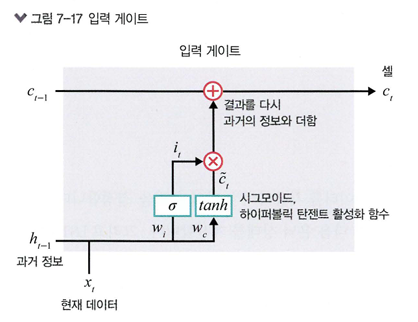

## 셀

각 단계에 대한 은닉 노드를 메모리 셀이라고 한다. '총합'을 사용하여 셀 값을 반영하며, 이것으로 기울기 소멸 문제가 해결된다.

셀을 업데이트하는 방법은 다음과 같다.

망각 게이트와 입력 게이트의 이전 단계 셀 정보를 계산하여 현재 단계의 셀 상태를 업데이트한다. 다음은 셀에 대한 수식이다.

$f_t$ = $σ$($w_f$[$h_{t-1}$,$x_t$])

$c_t$ = $c_{t-1}$ + $i_t$ $\widetilde{c}_{t}$

그림으로는 다음과 같이 표현할 수 있다.

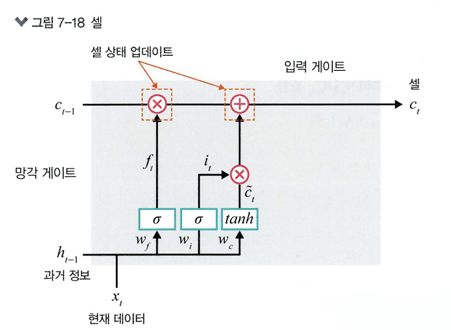

## 출력 게이트

출력 게이트는 과거 정보와 현재 데이터를 사용하여 뉴런의 출력을 결정한다. 이전 은닉 상태와 $t$번째 입력을 고려해서 다음 은닉 상태를 계산한다. 그리고 LSTM에서는 이 은닉 상태가 그 시점에서의 출력이 된다.

* 계산한 값이 1이면 의미 있는 결과로 최종 출력
* 계산한 값이 0이면 해당 연산 출력을 하지 않음

이것을 수식으로 정리하면 다음과 같다.

$σ_t$ = $σ$($w_σ$[$h_{t-1}$,$x_t$])
$h_t$ = $σ_t$ $tanh$($c_{t-1}$)

그림으로는 다음과 같이 표현 가능하다.

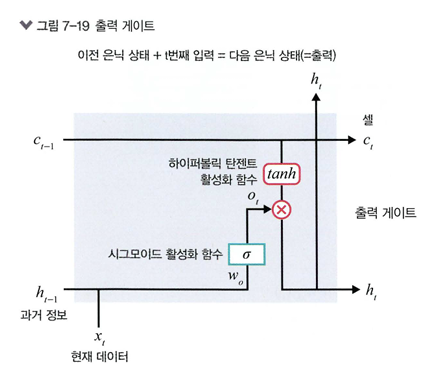

다음 그림은 망각 게이트, 입력 게이트, 출력 게이트를 모두 표현한 것이다.

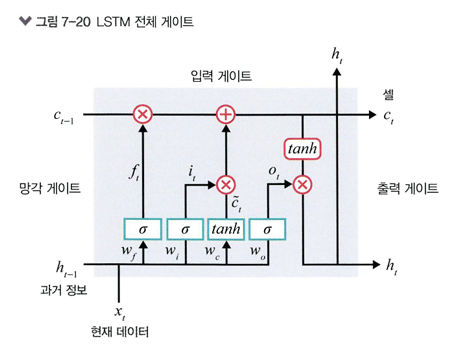

## LSTM 역전파

LSTM은 셀을 통해서 역전파를 수행하기 때문에 '중단 없는 기울기'라고도 한다.

즉, 다음 그림과 같이 최종 오차는 모든 노드에 전파되는데, 이때 셀을 통해서 중단 없이 전파된다.

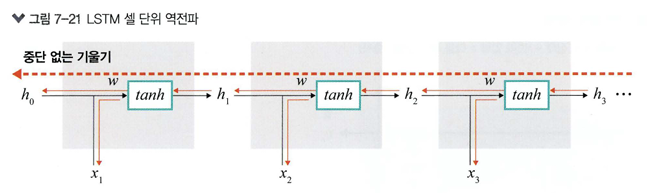

다음은 역전파를 수행하기 위한 공식이다.

$t_t$ = $tanh$($w_{hh}$$h_{t-1}$ +$w_{hh}$$x_t$)

= $tanh$(($w_{hh}$ $w_{sh}$)$\binom{h_{t-1}}{x_t}$)

= $tanh$($w$$\binom{h_{t-1}}{x_t}$)

이때 주의해야 할 것은 셀 단위로 오차가 전파된다고 해서 입력 방향으로 오차가 전파되지 않는 것은 아니다. 다음 그림과 같이 셀 내부적으로는 오차가 입력($x_t$)으로 전파된다는 것도 잊지 말아야 한다.


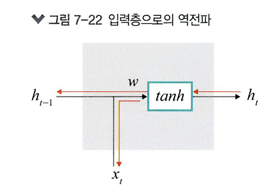

이제 LSTM을 파이토치로 구현해보자.

## 7.5.2 LSTM 셀 구현

지금까지 RNN을 살펴보았다면 이제 LSTM 셀과 LSTM 계층을 살펴보자. 이번 예제에서 사용할 데이터셋은 MNIST이다.

## MNIST

MNIST는 인공지능 연구의 권위자 얀 르쿤 교수가 만든 데이터셋으로 훈련 데이터셋 6만 개와 검증 데이터셋 1만 개로 구성되어 있다. MNIST는 손으로 쓴 숫자 이미지(0에서 9까지 값을 갖는 고정 크기 이미지(28*28 픽셀))들로 구성되어 있다.



In [1]:
# 라이브러리 호출

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dataset
from torch.autograd import Variable
from torch.nn import Parameter # 파라미터 목록을 갖는 라이브러리
from torch import Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math #수학과 관련되어 다양한 함수들과 상수들이 정의되어 있는 라이브러리

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
cuda = True if torch.cuda.is_available() else False # GPU 사용에 필요
Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor # GPU 사용에 필요

torch.manual_seed(125)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(125)

In [2]:
# datapreprocessing

import torchvision.transforms as transforms

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(1.0,)) # 평균을 0.5, 표준편차는 1.0으로 데이터 정규화
])

In [3]:
# 데이터셋 내려받기

from torchvision.datasets import MNIST

download_root = '../chap07/MNIST_DATASET'
train_dataset = MNIST(download_root, transform=mnist_transform, train=True, download=True) # 1
valid_dataset = MNIST( download_root, transform=mnist_transform, train=False, download=True)
test_dataset = MNIST( download_root, transform=mnist_transform, train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 133MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 12.7MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 80.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.96MB/s]


1. MNIST 데이터셋을 내려받기 위해 필요한 파라미터는 다음과 같다.



```
train_dataset = MNIST(download_root, transform=mnist_transform, train=True,download=True)
```



In [4]:
# 데이터셋을 메모리로 가져오기

batch_size = 64
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=batch_size,
                          shuffle=True)
valid_loader = DataLoader(dataset=test_dataset,
                          batch_size=batch_size,
                          shuffle=True)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=batch_size,
                         shuffle=True)

In [5]:
# 변수 값 지정

batch_size=100
n_iters=6000
num_epochs=n_iters/(len(train_dataset)/batch_size)
num_epochs=int(num_epochs)

In [6]:
# LSTM 셀 네트워크 구축

class LSTMCell(nn.Module ):
  def __init__ (self, input_size, hidden_size, bias=True):
    super(LSTMCell, self).__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.bias = bias
    self.x2h = nn.Linear(input_size, 4 * hidden_size, bias=bias) # 1
    self.h2h = nn.Linear(hidden_size, 4 * hidden_size, bias=bias) # 1'
    self.reset_parameters()

  def reset_parameters(self): # 모델의 파라미터 초기화
    std = 1.0 / math.sqrt(self.hidden_size)
    for w in self.parameters():
      w.data.uniform_(-std, std) # 2

  def forward(self, x, hidden):
    hx, cx = hidden
    x = x.view(-1, x.size(1))

    gates = self.x2h(x) + self.h2h(hx ) # 1''
    gates = gates.squeeze () # 3
    ingate, forgetgate, cellgate, outgate = gates.chunk(4, 1) # 1'''

    ingate = F.sigmoid(ingate) # 입력 게이트에 시그모이드 활성화 함수 적용
    forgetgate = F.sigmoid(forgetgate) # 망각 게이트에 시그모01드 활성화 함수 적용
    cellgate = F.tanh(cellgate) # 셀 게이트에 탄젠트 활성화 함수 적용
    outgate = F.sigmoid(outgate) # 출력 게이트에 시그모이드 활성화 함수 적용

    cy = torch.mul(cx, forgetgate) + torch.mul(ingate, cellgate) # 4
    hy = torch.mul(outgate, F.tanh(cy )) # 4'
    return (hy, cy)

1, 1' self.x2h = nn.Linear(input_size, 4*hidden_size, bias = bias)와 self.h2h = nn.Linear(hidden_size, 4*hidden_size, bias=bias)에서 4*hidden_size가 사용되고 있는 이유는 무엇일까? 왜 은닉칭의 뉴런/유닛에 4를 곱할까? 다음 그림을 먼저 이해해 보자.

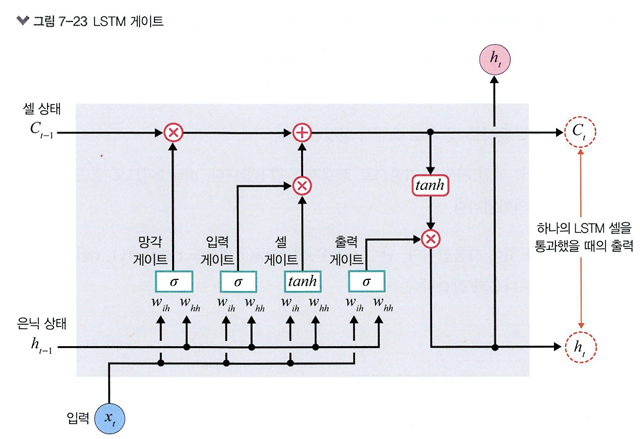

그림 7-23과 같이 LSTM에서 중요한 것은 게이트이다. 게이트는 망각, 입력, 셀, 출력으로 구성되며 이 모든 게이트는 1''처럼 구할 수 있다.1''를 풀어서 작성하면 다음과 같다.



```
gates = F.linear(input, w_ih, b_ih) + F.linear(hx, w_hh, b_hh)
```

이렇게 계산된 게이트(gates)는 1'''처럼 gates.chunk(4, 1)에 의해 네 개로 쪼개져서 각각 망각, 입력, 셀, 출력 게이트를 의미하는 변수에 저장된다. 즉， gates가 네 개로 쪼개지는 상황이기 때
문에 4가 곱해졌던 것이다. 일반적으로 바이어스도 4를 곱해 주지만 예제에서는 은닉층의 뉴런/유닛 개수만 4를 곱해 주었다.




또한, 여기에서 사용되는 torch.chunk() 사용 방법은 다음과 같다.

torch.chunk는 텐서를 쪼갤 때 사용하는 함수이며 파라미터는 다음과 같다.



```
ingate, forgetgate, cellgate, outgate = gates.chunk(4,1)
```

2. uniform()은 난수를 위해 사용한다. 난수 사용은 uniform() 외에도 randint(), random() 등이 있다.

3. torch.squeeze()는 텐서의 차원을 줄이고자 할 때 사용한다.

4, 4'. 하나의 LSTM 셀을 통과하면 셀($c_t$) 상태와 은닉 상태($h_t$)가 출력으로 주어진다. 이때 셀 상태는 입력, 망각, 셀 게이트에 의해 계산되며, 은닉 상태는 출력 게이트에 의해 계산된다. torch.null()은 텐서에 곱셉을 할 때 사용한다.



In [8]:
# LSTM 셀의 전반적인 네트워크

class LSTMModel(nn.Module):
  def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, bias=True):
    super(LSTMModel, self).__init__()
    self.hidden_dim = hidden_dim # 은닉층의 뉴런/유닛 개수

    self.layer_dim = layer_dim
    self.lstm = LSTMCell(input_dim, hidden_dim) # 1
    self.fc = nn.Linear(hidden_dim, output_dim)

  def forward(self, x):
    if torch.cuda.is_available(): # GPU 사용 유무 확인
      h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda()) # (은닉층의 계층 개수, 배치 크기, 은닉층의 뉴런 개수) 형태를 갖는 은닉 상태를 0으로 초기화
    else:
      h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim))

    if torch.cuda.is_available(): # GPU 사용 유무 확인
      c0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda()) # (은닉층의 계층 개수, 배치 크기, 은닉층의 뉴런 개수) 형태를 갖는 셀 상태를 0으로 초기화
    else:
      c0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim))

    outs = []
    cn = c0[0,:,:] # (은닉층의 계층 개수, 배치 크기, 은닉층의 뉴런 개수) 형태를 갖는 셀 상태를 0으로 초기화
    hn = h0[0,:,:] # (은닉층의 계층 개수, 배치 크기, 은닉층의 뉴런 개수) 크기를 갖는 은닉 상태에 대한 텐서

    for seq in range(x.size(1)): # LSTM 셀 계층을 반복하여 쌓아 올림
      hn, cn = self.lstm(x[:,seq,:], (hn, cn)) # 은닉 상태(hn)와 셀 상태를 LSTMCell에 적용한 결과를 또다시 hn, cn에 저장
      outs.append(hn)

    out = outs[-1].squeeze()
    out = self.fc(out)
    return out

1. LSTM 셀은 앞에서 정의한 함수를 불러오는 부분으로 파라미터는 다음과 같다.



```
self.lstm = LSTM(input_dim, hidden_dim, layer_dim)
```



In [9]:
# 옵티마이저와 손실 함수 지정

input_dim = 28
hidden_dim = 128
layer_dim = 1
output_dim = 10

model = LSTMModel(input_dim, hidden_dim, layer_dim, output_dim)
if torch.cuda.is_available(): # GPU 사용 유무 확인
  model.cuda()
criterion = nn.CrossEntropyLoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [10]:
# 모델 학습 및 성능 확인

seq_dim = 28
loss_list = []
iter = 0
for epoch in range(num_epochs):
  for i, (images, labels) in enumerate(train_loader): # 훈련 데이터셋을 이용한 모델 학습
    if torch.cuda.is_available(): # GPU 사용 유무 확인
      images = Variable(images.view(-1, seq_dim, input_dim).cuda()) # 1
      labels = Variable(labels.cuda())
    else: # GPU를 사용하지 않기 떄문에 else 구문이 실행
      images = Variable(images.view(-1, seq_dim, input_dim))
      labels = Variable(labels)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels) # 손실 함수를 이용하여 오차 계산

    if torch.cuda.is_available():
      loss.cuda()

    loss.backward()
    optimizer.step() # 파라미터 업데이트
    loss_list.append(loss.item())
    iter += 1

    if iter % 500 == 0: # 정확도(accuracy) 계산
      correct = 0
      total = 0
      for images, labels in valid_loader: # 검증 데이터셋을 이용한 모델 성능 검증

        if torch.cuda.is_available():
          images = Variable(images.view(-1, seq_dim, input_dim).cuda())
        else:
          images = Variable(images.view(-1, seq_dim, input_dim))

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) # 모델을 통과한 결과의 최댓값으로부터 예측 결과 가져오기

        total += labels.size(0) # 총 레이블 수
        if torch.cuda.is_available():
          correct += (predicted.cpu() == labels.cpu()).sum()
        else:
          correct += (predicted == labels).sum()

      accuracy = 100 * correct / total
      print('Iteration: {}. Loss: {}. Accuracy: {}'.format(iter, loss.item(), accuracy))

Iteration: 500. Loss: 2.237457513809204. Accuracy: 21.420000076293945
Iteration: 1000. Loss: 0.8865489363670349. Accuracy: 75.66000366210938
Iteration: 1500. Loss: 0.36925092339515686. Accuracy: 89.68000030517578
Iteration: 2000. Loss: 0.22741778194904327. Accuracy: 93.22000122070312
Iteration: 2500. Loss: 0.04691021144390106. Accuracy: 95.62999725341797
Iteration: 3000. Loss: 0.05541188269853592. Accuracy: 95.95999908447266
Iteration: 3500. Loss: 0.08951079845428467. Accuracy: 96.51000213623047
Iteration: 4000. Loss: 0.02204427309334278. Accuracy: 96.95999908447266
Iteration: 4500. Loss: 0.07599193602800369. Accuracy: 96.76000213623047
Iteration: 5000. Loss: 0.05491260439157486. Accuracy: 97.11000061035156
Iteration: 5500. Loss: 0.16436734795570374. Accuracy: 96.5199966430664
Iteration: 6000. Loss: 0.01572381891310215. Accuracy: 97.20999908447266
Iteration: 6500. Loss: 0.01401564758270979. Accuracy: 97.88999938964844
Iteration: 7000. Loss: 0.01943875104188919. Accuracy: 97.91999816894

In [13]:
# 테스트 데이터셋을 이용한 모델 예측 성능 확인

def evaluate(model, val_iter):
  corrects, total, total_loss = 0, 0, 0
  model.eval()
  for images, labels in val_iter:
    if torch.cuda.is_available(): # GPU 사용 유무 확인
      images = Variable(images.view(-1, seq_dim, input_dim).cuda())
      labels = labels.cuda()
    else:
      images = Variable(images.view(-1, seq_dim, input_dim)).to(device)
      labels = labels.to(device)

    logit = model(images).to(device)
    loss = F.cross_entropy(logit, labels, reduction="sum") # reduction = 'sum'을 지정했기 때문에 모든 오차를 더함.
    _, predicted = torch.max(logit.data, 1) # logit.data 텐서에서 최댓값의 인덱스를 반환
    total += labels.size(0)
    total_loss += loss.item()
    corrects += (predicted == labels).sum()

  avg_loss = total_loss / len(val_iter.dataset)
  avg_accuracy = corrects / total
  return avg_loss, avg_accuracy

In [14]:
# 모델 예측 성능 확인

test_loss, test_acc = evaluate(model, test_loader)
print("Test Loss: %5.2f : Test Accuracy: %5.2f"%(test_loss, test_acc))

Test Loss:  0.07 : Test Accuracy:  0.98


IMDB에서 MNIST로 데이터셋이 바뀌기는 했지만 98%로 성능이 매우 좋다.IMDB는 사전에 전처리가 되지 않은 데이터셋이고 MNIST는 사전에 전처리가 된 상태의 데이터셋이기 때문에
정확도 측면에서 차이가 날 수 있다. 이와 같이 사전에 전처리가 되지 않은 데이터셋의 경우 정
확도를 높이기 위해 은닉층의 개수(혹은 뉴런의 개수) 및 하이퍼파라미터 수정 등이 필요하다.

## 7.5.3 LSTM 계층 구현

LSTM 계층에 대한 예제 데이터셋은 스타벅스 주가 데이터셋을 시용한다. 또한, 예제를 통해 확인하고자 하는 것은 모델이 얼마나 주가 예측을 잘 하는지에 대해 알아보는 것이다.

In [15]:
# 라이브러리 호출

import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

device = torch.device('cud:0' if torch.cuda.is_available() else 'cpu')

In [20]:
# 데이터셋 가져오기
!git clone https://github.com/gilbutITbook/080289.git
data_path =  '080289/chap07/data/SBUX.csv'
data = pd.read_csv(data_path)
print(data.dtypes)

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 2278 (delta 1), reused 0 (delta 0), pack-reused 2273 (from 2)
Receiving objects: 100% (2278/2278), 330.30 MiB | 33.27 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


데이터셋에 포함된 ‘Date’ 칼럼을 인텍스로 시용하도록 한다. 이번 예제에서 사용할 데이터들은 숫자이기 때문에 임베딩이 필요하지 않지만 단어들로 구성된 데이터셋은 임베딩 과정을 거쳐야 한다. 이때 날짜 칼럼은 임베딩 처리가 어려운 경우가 많은데, 날짜 칼럼을 인텍스로 처리하면 편리하다.

In [21]:
# 날짜 칼럼을 인덱스로 사용

data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True) # 'date' 칼럼을 인덱스로 사용

'Volume' 칼럼은 정수(int)라는 데이터 형식을 갖는데, 이것을 실수(float)로 변경한다. 여기도 마찬가지로 데이터 형식을 실수(float)로 맞추고 시작하면 추후 데이터를 댄서로 변환할 때 편리하다.

In [22]:
data['Volume'] = data['Volume'].astype(float) # 데이터 형식을 변경할 때는 astype()을 사용

In [23]:
# 훈련과 레이블 분리

X = data.iloc[:, :-1] #  마지막 칼럼을 제외한 모든 칼럼을 X로 사용
y = data.iloc[:, 5:6] # 마지막 'Volums'을 레이블로 사용
print(X)
print(y)

                  Open        High         Low       Close   Adj Close
Date                                                                  
2019-12-11   86.260002   86.870003   85.849998   86.589996   84.145752
2019-12-12   88.000000   88.889999   87.540001   88.209999   85.720032
2019-12-13   88.019997   88.790001   87.580002   88.669998   86.167046
2019-12-16   89.139999   89.300003   88.430000   88.779999   86.273941
2019-12-17   88.870003   88.970001   87.470001   88.129997   85.642288
...                ...         ...         ...         ...         ...
2020-12-04  101.349998  102.940002  101.070000  102.279999  101.442787
2020-12-07  102.010002  102.220001  100.690002  101.410004  100.579918
2020-12-08  100.370003  101.570000  100.010002  101.209999  100.381554
2020-12-09  101.940002  102.209999  100.099998  100.400002   99.578186
2020-12-10  103.510002  106.089996  102.750000  105.389999  104.527336

[253 rows x 5 columns]
                Volume
Date                  
2019-12

In [24]:
# 데이터 분포 조정

ms = MinMaxScaler() # 데이터의 모든 값이 0~1 사이에 존재하도록 분산 조정
ss = StandardScaler() # 데이터가 평균 0, 분산 1이 되도록 분산 조정

X_ss = ss.fit_transform(X)
y_ms = ms.fit_transform(y)

X_train = X_ss[:200, :] # 훈련 데이터셋
X_test = X_ss[200:, :] # 테스트 데이터셋

y_train = y_ms[:200, :]
y_test = y_ms[200:, :]

print("Training Shape", X_train.shape, y_train.shape)
print("Testing Shape", X_test.shape, y_test.shape)

Training Shape (200, 5) (200, 1)
Testing Shape (53, 5) (53, 1)


In [25]:
# 데이터셋의 형태 및 크기 조정

X_train_tensors = Variable(torch.Tensor(X_train)) # Variable로 감싸진 텐서는 .backward()가 호출될 때 자동으로 기울기가 계산
X_test_tensors = Variable(torch.Tensor(X_test))

y_train_tensors = Variable(torch.Tensor(y_train))
y_test_tensors = Variable(torch.Tensor(y_test))

X_train_tensors_f = torch.reshape(X_train_tensors, (X_train_tensors.shape[0], 1, X_train_tensors.shape[1])) # 1
X_test_tensors_f = torch.reshape(X_test_tensors, (X_test_tensors.shape[0], 1, X_test_tensors.shape[1]))

print("Training Shape", X_train_tensors_f.shape, y_train_tensors.shape)
print("Testing Shape", X_test_tensors_f.shape, y_test_tensors.shape)

Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


In [26]:
# LSTM 네트워크

class LSTM(nn.Module):
  def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
    super(LSTM, self).__init__()
    self.num_classes = num_classes # 클래스 개수
    self.num_layers = num_layers # LSTM 계층의 개수
    self.input_size = input_size # 입력 크기로 훈련 데이터셋의 칼럼 개수를 의미
    self.hidden_size = hidden_size # 은닉층의 뉴런 개수
    self.seq_length = seq_length # 시퀀스 길이

    self.lstm = nn.LSTM(input_size = input_size, hidden_size = hidden_size,
                        num_layers = num_layers, batch_first = True) # LSTM 계층
    self.fc_1 = nn.Linear(hidden_size, 128) # 완전연결층
    self.fc = nn.Linear(128, num_classes) # 출력층
    self.relu = nn.ReLU()

  def forward(self, x):
    h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) # 은닉 상태를 0으로 초기화
    c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) # 셀 상태를 0으로 초기화
    output, (hn, cn) = self.lstm(x, (h_0, c_0)) # LSTM 계층에 은닉 상태와 셀 상태 적용
    hn = hn.view(-1, self.hidden_size) # 완전연결층 적용을 위해 데이터의 형태 조정(1차원으로 조정)
    out = self.relu(hn)
    out = self.fc_1(out)
    out = self.relu(out)
    out = self.fc(out)
    return out

In [27]:
# 변수 값 설정

num_epochs = 1000 # 1000번의 에포크
learning_rate = 0.0001 # 학습률을 0.0001로 지정

input_size = 5 # 입력 데이터셋의 칼럼 개수
hidden_size = 2 # 은닉층의 뉴런/유닛 개수
num_layers = 1 # LSTM 계층의 개수

num_classes = 1 # 클래스 개수
model = LSTM(num_classes, input_size, hidden_size, num_layers, X_train_tensors_f.shape[1]) # 앞에서 정의한 값들을 이용하여 LSTM 모델 학습

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

In [28]:
# 모델 학습

for epoch in range(num_epochs): # 1000번 반복
  outputs = model.forward(X_train_tensors_f) # 전방향(forward) 학습
  optimizer.zero_grad()
  loss = criterion(outputs, y_train_tensors) # 손실 함수를 이용한 오차 계산(모델 학습 결과와 레이블의 차이 계산)
  loss.backward() # 기울기 계산

  optimizer.step() # 오차 업데이트
  if epoch % 100 == 0: # 1000을 100으로 나누어 나머지가 0이면 출력
    print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

Epoch: 0, loss: 0.18287
Epoch: 100, loss: 0.05713
Epoch: 200, loss: 0.03855
Epoch: 300, loss: 0.03717
Epoch: 400, loss: 0.03599
Epoch: 500, loss: 0.03326
Epoch: 600, loss: 0.02937
Epoch: 700, loss: 0.02517
Epoch: 800, loss: 0.02214
Epoch: 900, loss: 0.02038


In [29]:
# 모델 예측 결과를 출력하기 위한 데이터 크기 재구성

df_x_ss = ss.transform(data.iloc[:, :-1]) # 데이터 정규화(분포 조정)
df_y_ms = ms.transform(data.iloc[:, -1:]) # 데이터 정규화

df_x_ss = Variable(torch.Tensor(df_x_ss))
df_y_ms = Variable(torch.Tensor(df_y_ms))
df_x_ss = torch.reshape(df_x_ss, (df_x_ss.shape[0], 1, df_x_ss.shape[1]))

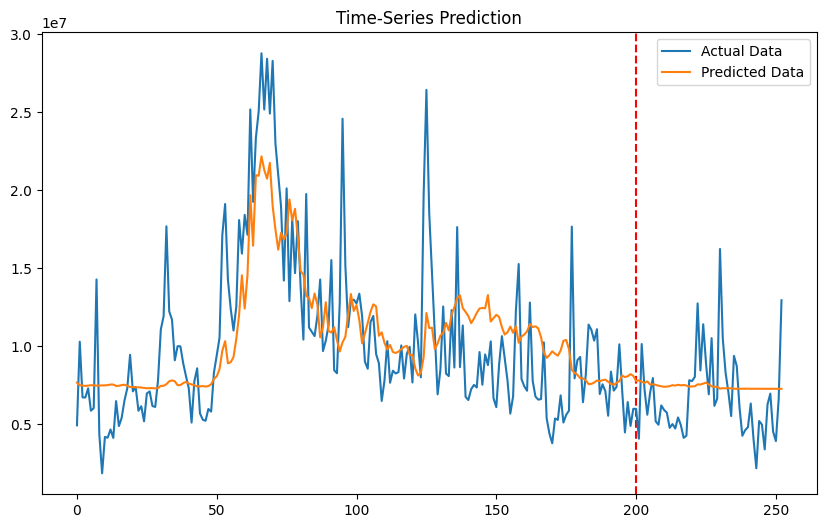

In [30]:
# 모델 예측 결과 출력

train_predict = model(df_x_ss) # 훈련 데이터셋을 모델에 적용하여 모델 학습
predicted = train_predict.data.numpy() # 모델 학습 결과를 넘파이로 변경
label_y = df_y_ms.data.numpy()

predicted = ms.inverse_transform(predicted) # 모델 학습을 위해 전처리(정규화)했던 것을 해제 (그래프의 본래 값을 출력하기 위한 목적)
label_y = ms.inverse_transform(label_y)
plt.figure(figsize = (10, 6)) # 그래프로 표시
plt.axvline(x=200, c='r', linestyle = '--') # 1

plt.plot(label_y, label = 'Actual Data')
plt.plot(predicted, label = 'Predicted Data')
plt.title('Time-Series Prediction')
plt.legend()
plt.show()